In [5]:
import os
import yaml

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
plt.rcParams["font.family"] = "serif"

import multiprocessing as mp
import time
import numpy as np
import itertools
import tools21cm as t2c

from scipy import stats
from tqdm import tqdm

import astropy.units as u
import astropy.constants as cst

In [6]:
#Summing two random numbers gives a sqrt(2) standard deviation

x= np.random.normal(0, 1, 1000)
y= np.random.normal(0, 1, 1000)

print(np.std(x+y))

# The standard deviation of the sum of two random variables depends on whether the variables are independent or not. 
# If two random variables, X and Y, are independent, then the variance of their sum, X + Y, is the sum of their individual variances.

# Mathematically, if X and Y are independent random variables, then:
# Var(X + Y) = Var(X) + Var(Y)

# Given that the standard deviation is the square root of the variance, we have:
# SD(X + Y) = sqrt(Var(X) + Var(Y))

# If both X and Y are standard normal random variables (i.e., with mean 0 and standard deviation 1), 
# then their variances are both 1. So, the standard deviation of their sum, X + Y, is:
# SD(X + Y) = sqrt(1 + 1) = sqrt(2)

# This result holds because standard normal random variables have mean 0 and are independent. 
# If the random variables are not standard normal or not independent, the standard deviation of their sum may differ.

1.4180136916200494


In [7]:
def galactic_synch_fg_custom(z, ncells, boxsize, rseed=False):
    """
    Simulated synchrotron emission. Simplified because of removed noise.
    """
    if(isinstance(z, float)):
        z = np.array([z])
    else:
        z = np.array(z, copy=False)

    gf_data = np.zeros((ncells, ncells, z.size))

    if(rseed): 
        np.random.seed(rseed)
	
    X  = np.random.normal(size=(ncells, ncells))
    Y  = np.random.normal(size=(ncells, ncells))
    nu_s,A150,beta_,a_syn,Da_syn = 150,5.13*1e-4,2.34,2.8,0.1
	
    for i in range(0, z.size):
        nu = t2c.cosmo.z_to_nu(z[i])
        U_cb  = (np.mgrid[-ncells/2:ncells/2,-ncells/2:ncells/2]+0.5)*t2c.cosmo.z_to_cdist(z[i])/boxsize
        l_cb  = 2*np.pi*np.sqrt(U_cb[0,:,:]**2+U_cb[1,:,:]**2)
        C_syn = A150*(1000/l_cb)**beta_
        solid_angle = boxsize**2/t2c.cosmo.z_to_cdist(z[i])**2
        AA = np.sqrt(solid_angle*C_syn/2)
        T_four = AA*(X+Y*1j) * np.sqrt(2)
        T_real = np.abs(np.fft.ifft2(T_four))   #in Jansky
        gf_data[..., i]= T_real
        #gf_data[..., i] = t2c.telescope_functions.jansky_2_kelvin(T_real*1e6, z[i], boxsize=boxsize, ncells=ncells)
        #gf_data[..., i] = t2c.telescope_functions.kelvin_2_jansky(T_real*1e6, z[i], boxsize=boxsize, ncells=ncells)
    
    return gf_data.squeeze(), l_cb

def synchrotron_image(z, ncells, boxsize, seed=False):
    if(seed): 
        np.random.seed(seed)

    X  = np.random.normal(size=(ncells, ncells))
    Y  = np.random.normal(size=(ncells, ncells))

    A150, beta= 5.13*1e-4, 2.34

    U_cb  = (np.mgrid[-ncells/2:ncells/2,-ncells/2:ncells/2]+0.5)*t2c.cosmo.z_to_cdist(z)/boxsize
    l_cb  = 2*np.pi*np.sqrt(U_cb[0,:,:]**2+U_cb[1,:,:]**2)
    C_syn = A150*(1000/l_cb)**beta
    solid_angle = boxsize**2/t2c.cosmo.z_to_cdist(z)**2
    AA = np.sqrt(solid_angle*C_syn/2)
    T_four = AA*(X+Y*1j)  * np.sqrt(2)
    T_real = np.abs(np.fft.ifft2(T_four))

    return T_real, l_cb

def telescope_beam_pattern(x, y, D, z):
    """
    Returns a 2D Gaussian array representing the telescope beam pattern.

    Parameters
    ----------
    x : ndarray
        Meshgrid x-coordinates.
    y : ndarray
        Meshgrid y-coordinates.
    D : float, optional
        Telescope dish diameter, in meters (default is 45).
    z : float, optional
        Redshift, which is converted to observation frequency (default is 7).

    Returns
    -------
    ndarray
        A 2D Gaussian array representing the telescope beam pattern.

    Notes
    -----
    The Gaussian array is calculated based on the provided dish diameter and redshift.
    """
    freq= t2c.cosmo.z_to_nu(z) * 10**6
    lam = cst.c.value / freq
    fwhm= 1.03*lam / D
    theta_0 = 0.6* fwhm
    return np.exp(-((x**2 + y**2) / theta_0**2))

def gaussian_source_2d(x, y, cov):
    """
    Calculate the value of a 2D Gaussian source at given coordinates (x, y).

    Parameters:
    - x (float): x-coordinate of the point.
    - y (float): y-coordinate of the point.
    - cov (list): Covariance matrix in arcseconds.

    Returns:
    - float: Value of the 2D Gaussian source at the given coordinates.

    Notes:
    - The covariance matrix takes two values provided in arcseconds.
    - The mean of the Gaussian source is assumed to be (0, 0).
    """
    mean = np.array([0, 0])  # Mean of the Gaussian source
    cov = np.array([[(cov[0] * u.arcsec).to('rad').value, 0], [0, (cov[1] * u.arcsec).to('rad').value]])
    x_diff = x - mean[0]
    y_diff = y - mean[1]
    inv_cov = np.linalg.inv(cov)
    exponent = -0.5 * (x_diff**2 * inv_cov[0, 0] + y_diff**2 * inv_cov[1, 1] + 2 * x_diff * y_diff * inv_cov[0, 1])
    prefactor = 1 / (2 * np.pi * np.sqrt(np.linalg.det(cov)))

    return prefactor * np.exp(exponent)

def hirax_layout(N_ant, range):
    """
    Generates a square grid layout of antennas, similar to HIRAX.

    Parameters
    ----------
    N_ant : int
        Number of antennas to generate.
    range : tuple
        Tuple specifying the range of coordinates in which antennas will be placed.
        It should be in the format (min_value, max_value).

    Returns
    -------
    ndarray
        An array containing the coordinates of the antennas arranged in a square grid.
        Each row represents the (x, y) coordinates of an antenna.
    """
    x= np.linspace(range[0], range[1], int(np.sqrt(N_ant)))
    X, Y= np.meshgrid(x, x)
    return np.dstack((X, Y)).reshape(-1, 2)

def random_layout(N_ant, range, seed):
    """
    Generates a random layout of antennas within the specified range.

    Parameters
    ----------
    N_ant : int
        Number of antennas to generate.
    range : tuple
        Tuple specifying the range of coordinates in which antennas will be placed.
        It should be in the format (min_value, max_value).
    seed : int
        Seed value for random number generation.

    Returns
    -------
    ndarray
        An array containing the coordinates of the randomly placed antennas.
        Each row represents the (x, y) coordinates of an antenna.
    """

    np.random.seed(seed)
    X= np.random.uniform(range[0], range[1], N_ant)
    Y= np.random.uniform(range[0], range[1], N_ant)

    return np.dstack((X,Y)).reshape(-1, 2)

def random_layout_concentrated(N_ant, range_large, range_small, seed):
    
    np.random.seed(seed)
    # Generate antennas within the larger range
    X_large = np.random.uniform(range_large[0], range_large[1], N_ant)
    Y_large = np.random.uniform(range_large[0], range_large[1], N_ant)
    
    # Generate antennas within the smaller range
    X_small = np.random.uniform(range_small[0], range_small[1], N_ant)
    Y_small = np.random.uniform(range_small[0], range_small[1], N_ant)

    # Concatenate the generated points from both ranges
    X = np.concatenate((X_large, X_small))
    Y = np.concatenate((Y_large, Y_small))

    return np.dstack((X,Y)).reshape(-1, 2)

def random_normal_layout(N_ant, range, seed):
    """
    Generates a random layout of antennas within the specified range.

    Parameters
    ----------
    N_ant : int
        Number of antennas to generate.
    range : tuple
        Tuple specifying the range of coordinates in which antennas will be placed.
        It should be in the format (min_value, max_value).
    seed : int
        Seed value for random number generation.

    Returns
    -------
    ndarray
        An array containing the coordinates of the randomly placed antennas.
        Each row represents the (x, y) coordinates of an antenna.
    """

    np.random.seed(seed)
    X= np.random.normal(range[0], range[1], N_ant)
    Y= np.random.normal(range[0], range[1], N_ant)

    return np.dstack((X,Y)).reshape(-1, 2)

def ring_layout(N_ring, N_center, radius_range, center_range, seed):
    """
    Generates a layout of antennas with a specified number of antennas in a ring and within the center.
    Antennas within the center can also be generated using the ring method.

    Parameters
    ----------
    N_ring : int
        Number of antennas to generate in the ring.
    N_center : int
        Number of antennas to generate within the center.
    radius_range : tuple
        Tuple specifying the range of the ring radius.
        It should be in the format (min_radius, max_radius).
    center_range : tuple
        Tuple specifying the range of coordinates in which antennas within the center will be placed.
        It should be in the format (min_value, max_value).
    seed : int
        Seed value for random number generation.

    Returns
    -------
    ndarray
        An array containing the coordinates of the randomly placed antennas.
        Each row represents the (x, y) coordinates of an antenna.
    """

    np.random.seed(seed)

    # Generate antennas in the ring
    theta_ring = np.random.uniform(0, 2*np.pi, N_ring)
    radius_ring = np.random.uniform(radius_range[0], radius_range[1], N_ring)
    X_ring = radius_ring * np.cos(theta_ring)
    Y_ring = radius_ring * np.sin(theta_ring)

    # Generate antennas within the center using the ring method
    theta_center = np.random.uniform(0, 2*np.pi, N_center)
    radius_center = np.random.uniform(0, min(center_range[1], max(radius_range)), N_center)
    X_center = radius_center * np.cos(theta_center)
    Y_center = radius_center * np.sin(theta_center)

    # Combine antennas from ring and center
    X = np.concatenate((X_ring, X_center))
    Y = np.concatenate((Y_ring, Y_center))

    return np.dstack((X,Y)).reshape(-1, 2)

def median_index(list):
    """
    Returns the index of the median value in a numpy list.

    Parameters:
    - list: numpy array or list
        The input array containing numerical values.

    Returns:
    - int
        The index of the element closest to the median value.

    Raises:
    - ValueError: If the input list is empty.
    """
    average = np.mean(list)
    closest_index = np.abs(list - average).argmin()
    return closest_index

def arbitrary_index(list, value):
    """
    Find the index of the closest element in a list to a given value.

    Parameters:
    list (array-like): The list of values.
    value (float): The value to find the closest index to.

    Returns:
    int: The index of the closest element in the list to the given value.
    """
    closest_index = np.abs(list - value).argmin()
    return closest_index

def visibility_matrix_func(xyz_coord, lmn_coord, redshift, I_sky, beam_pattern):
    """
    Compute the visibility matrix for a given set of antennas and sky image.

    Parameters
    ----------
    xyz_coord : array_like
        Array of x, y, and z coordinates of antennas.
    lmn_coord : array_like
        Array of l, m, and n coordinates representing the direction of the sky image.
    redshift : float
        Redshift observed with 21-cm.
    I_sky : array_like
        Array containing the intensity of the sky image.
    beam_pattern : array_like
        Array representing the beam pattern of the telescope.

    Returns
    -------
    visibility_list : ndarray
        A 1D array of length N_B containing visibility values for each baseline.
    visibility_matrix : ndarray
        A 2D array representing the visibility matrix with shape (N_ant, N_ant).
    """
    N_ant= len(xyz_coord) #Number of antennas
    N_B= int(N_ant*(N_ant-1) / 2) #Number of baselines
    freq = t2c.cosmo.z_to_nu(redshift) * 10**6
    lam = cst.c.value / freq

    pair_comb= list(itertools.combinations(range(N_ant), 2)) #Get pair of antennas

    baseline_coord= np.empty((N_B, xyz_coord.shape[1])) #Initialize a baseline vectors array
    visibility_matrix= np.zeros((N_ant, N_ant), dtype=np.complex128) #Initialize a visibility array
    visibility_list= np.empty(N_B, dtype=np.complex128) #Initialize a visibility list

    for i in tqdm(range(N_B)):
        aa, bb= pair_comb[i]

        #Calculate distance between antennas
        uv= ((xyz_coord[bb]- xyz_coord[aa]) / lam)
        baseline_coord[i]= uv

        #Calculate the fringe pattern
        fringe= np.exp(-2j * np.pi * (uv[0] * lmn_coord[:,0] + uv[1] * lmn_coord[:,1]))

        #Reshape fringe_pattern to match the shape of I_sky
        fringe_reshaped = fringe.reshape(I_sky.shape)

        #Calculate visibility for the current baseline
        visibility= np.sum(fringe_reshaped * I_sky * beam_pattern)

        visibility_list[i]= visibility

        #Store the visibility value in the array
        visibility_matrix[aa, bb] = visibility
        visibility_matrix[bb, aa] = np.conj(visibility) #Visibility is symmetric

    return visibility_list, visibility_matrix, baseline_coord

def visibility_rotation_synthesis(lmn_coord, rotated_baselines, I_sky, beam_pattern, N_ant):
    N_B= int(N_ant*(N_ant-1) / 2)

    assert np.shape(rotated_baselines)[0] == N_B

    pair_comb= list(itertools.combinations(range(N_ant), 2)) #Get pair of antennas
    visibility_matrix= np.zeros((N_ant, N_ant), dtype=np.complex128) #Initialize a visibility array
    visibility_list= np.empty(N_B, dtype=np.complex128) #Initialize a visibility list

    for i in range(N_B):
        aa, bb= pair_comb[i]
        uv= rotated_baselines[i]
        fringe= np.exp(-2j * np.pi * (uv[0] * lmn_coord[:,0] + uv[1] * lmn_coord[:,1]))
        fringe_reshaped = fringe.reshape(I_sky.shape)
        visibility= np.sum(fringe_reshaped * I_sky * beam_pattern)
        visibility_list[i]= visibility

        visibility_matrix[aa, bb]=visibility
        visibility_matrix[bb, aa] = np.conj(visibility)

    return visibility_list, visibility_matrix

def Earth_Rotation_Effect(HA, delta):
    HA, delta = HA.to('rad').value, delta.to('rad').value
    
    return np.array([[np.sin(HA), np.cos(HA)], 
                     [-np.sin(delta)*np.cos(HA), np.sin(delta)*np.sin(HA)]])

def visibility_correlation_func(index, baseline_coord, visibility_list, N_B):
    """
    Computes visibility correlation and baseline distances from a given baseline index.

    Parameters:
    - index: int
        Index of the baseline vector.
    - baseline_coord: numpy.ndarray
        Array containing baseline coordinates.
    - visibility_list: numpy.ndarray
        Array containing visibility values.
    - N_B: int
        Total number of baseline vectors.

    Returns:
    - vis_corr: numpy.ndarray
        Array of visibility correlations.
    - baseline_distances_norm: numpy.ndarray
        Array of normalized baseline distances.
    """
    indices= np.linspace(0, N_B-1, N_B)
    indices_combinations= list(itertools.product([index], range(N_B))) #Generate combinations
    baseline_distances= np.empty((len(indices), 2)) #Create empty array for calculating distance between two vectors
    vis_corr= np.empty(len(indices), dtype=np.complex128)

    for i in range(len(indices)):
        ii, jj = indices_combinations[i]
        vis_corr[i]= visibility_list[ii] * np.conj(visibility_list[jj])
        baseline_distances[i]= baseline_coord[jj] - baseline_coord[ii]

    baseline_distances_norm= np.linalg.norm(baseline_distances, axis=1)

    return vis_corr.real, baseline_distances_norm

def visibility_matrix_func_new_method(xyz_coord, sky_coord, redshift, I_sky, beam_pattern):
    l_coord, m_coord= np.meshgrid(sky_coord, sky_coord)
    N_ant= len(xyz_coord)
    N_B= int(N_ant*(N_ant-1) / 2)
    freq = t2c.cosmo.z_to_nu(redshift) * 10**6
    lam = cst.c.value / freq
    pair_comb= list(itertools.combinations(range(N_ant), 2))
    baseline_coord= np.empty((N_B, xyz_coord.shape[1]))
    visibility_matrix= np.zeros((N_ant, N_ant), dtype=np.complex128)
    visibility_list= np.empty(N_B, dtype=np.complex128)

    for i in tqdm(range(N_B)):
        aa, bb= pair_comb[i]
        uv= (xyz_coord[bb]- xyz_coord[aa]) / lam
        baseline_coord[i]= uv
        fringe= np.exp(-2j * np.pi * (uv[0] * l_coord + uv[1] * m_coord))
        vis= np.sum(fringe * I_sky * beam_pattern)
        visibility_list[i]= vis
        visibility_matrix[aa, bb]= vis
        visibility_matrix[bb, aa]= np.conj(vis)
    
    return visibility_list, visibility_matrix, baseline_coord
    
def image_reconstructing_func(vis_list, baselines, u_min, u_max, bin_len, bin_res):
    """
    Reconstructs an image from visibility data using interferometry.

    Parameters:
    vis_list (array-like): List of visibility values.
    baselines (array-like): List of baseline coordinates.
    u_min (float): Minimum value of the u-coordinate.
    u_max (float): Maximum value of the u-coordinate.
    bin_len (float): Length of the bin.
    bin_res (float): Resolution of the bin.

    Returns:
    array-like: Reconstructed image.
    """
    uv_bin= np.linspace(u_min, u_max, int(bin_len/ bin_res))
    
    uv_plane_binned= stats.binned_statistic_2d(x=baselines[:,0], y=baselines[:,1], values= vis_list,
                                               statistic='sum', bins=[uv_bin, uv_bin]).statistic
    uv_sampl_binned= stats.binned_statistic_2d(x=baselines[:,0], y=baselines[:,1], values= vis_list,
                                               statistic='count', bins=[uv_bin, uv_bin]).statistic
    uv_plane_binned /= np.where(uv_sampl_binned > 0, uv_sampl_binned, 1)

    x= np.fft.fftshift(np.fft.fftfreq(len(uv_bin), np.diff(uv_bin)[0]))

    return uv_plane_binned, uv_bin, uv_sampl_binned, x

def powerspec_1d(uv_bins, fft_img, FoV):

    solid_angle = 2 * np.pi * (1 - np.cos(np.deg2rad(FoV.value * u.deg / 2)))
    
    if len(fft_img)==len(uv_bins):
        uv_mesh= np.meshgrid(uv_bins, uv_bins)
        uv_mesh_stacked= np.stack((uv_mesh[1], uv_mesh[0]), axis=-1)
        uv_list= uv_mesh_stacked.reshape((len(uv_bins)**2, 2))

    else:
        uv_mesh= np.meshgrid(uv_bins[0:-1], uv_bins[0:-1])
        uv_mesh_stacked= np.stack((uv_mesh[1], uv_mesh[0]), axis=-1)
        uv_list= uv_mesh_stacked.reshape((len(uv_bins[0:-1])**2, 2))

    
    l= 2*np.pi*(uv_list[:,0]**2 + uv_list[:,1]**2)**0.5 
    
    fftimg_abs= np.abs(fft_img)**2 / solid_angle
    fftimg_abs_reshape= fftimg_abs.reshape(-1)

    fft_img_binned= stats.binned_statistic(l, fftimg_abs_reshape, statistic='mean', bins=len(uv_bins)-1)
    bin_centre= [(fft_img_binned.bin_edges[i] + fft_img_binned.bin_edges[i+1]) / 2 for i in range(len(fft_img_binned.bin_edges)-1)]
    
    return np.array(bin_centre), np.array(fft_img_binned.statistic)

def filter_baselines(baselines, visibilities, u_freq, v_freq):
    filtered_baselines = []
    filtered_visibilities= []

    for baseline, visibility in zip(baselines, visibilities):
        x, y = baseline
        # Check if baseline coordinates are within the range of frequencies
        if (np.min(u_freq) <= x <= np.max(u_freq)) and (np.min(v_freq) <= y <= np.max(v_freq)):
            filtered_baselines.append(baseline)
            filtered_visibilities.append(visibility)
    return np.array(filtered_baselines), np.array(filtered_visibilities)

def bare_estimator_func(baselines, visibilities, rshift, D, num_bins, bin_type='log'):
    freq = t2c.cosmo.z_to_nu(rshift) * 10**6
    lam = cst.c.value / freq
    fwhm = 1.03 * lam / D
    sigma_0 = 0.76 / fwhm
    theta_0 = 0.6* fwhm
    V_0 = np.pi * theta_0**2 / 2

    bl_mag= np.linalg.norm(baselines, axis=1)
    blcoord_blmag_vis= zip(baselines, bl_mag, visibilities)
    sorted_blcoord_blmag_vis= sorted(blcoord_blmag_vis, key=lambda x: x[1])
    blcoord_sorted, blmag_sorted, vis_sorted= zip(*sorted_blcoord_blmag_vis)

    if bin_type == 'log':
        log_blmag_sorted= np.log10(blmag_sorted)
    if bin_type == 'linear':
        log_blmag_sorted= blmag_sorted
    bins= np.linspace(np.min(log_blmag_sorted), np.max(log_blmag_sorted), num_bins)
    bin_indices= np.digitize(log_blmag_sorted, bins)

    # Initialize a dictionary to store the baseline coordinates, baseline magnitudes and visibility values
    bin_values= {i: [] for i in range(1, num_bins+1)}
    # Group the y values based on the bin indices
    for i, bin_index in enumerate(bin_indices):
        bin_values[bin_index].append((blcoord_sorted[i], blmag_sorted[i], vis_sorted[i]))

    bare_estimator= []
    ell_mean= []
    estimate= []

    for key in bin_values.keys():
        bin_len= len(bin_values[key])

        print("Key: ", key, "; Key legnth: ", bin_len, "; Combinations: ", bin_len*(bin_len-1)/2)

    for key in bin_values.keys():
        bin_len= len(bin_values[key])

        if bin_len == 0 or bin_len == 1:
            continue

        print("Key: ", key, "; Key legnth: ", bin_len, "; Combinations: ", bin_len*(bin_len-1)/2)

        numerator= 0
        denominator= 0
        est_numerator= 0
        est_denominator= 0
        ell_numerator= 0
        ell_denominator= 0
        pair_combs= list(itertools.combinations(range(bin_len), 2))

        for i in range(len(pair_combs)):
            distance= bin_values[key][pair_combs[i][0]][0] - bin_values[key][pair_combs[i][1]][0]
            distance_norm= np.linalg.norm(distance)
            weight= np.exp(-distance_norm**2 / sigma_0**2)

            visibility_product= bin_values[key][pair_combs[i][0]][2] * np.conj(bin_values[key][pair_combs[i][1]][2])
            numerator += weight * visibility_product
            denominator += weight * V_0 * np.exp(-distance_norm**2 / (sigma_0**2))
                    
            u_i= bin_values[key][pair_combs[i][0]][0][0]
            v_i= bin_values[key][pair_combs[i][0]][0][1]
            l_i= 2 * np.pi * (u_i**2 + v_i**2)**0.5
            ell_numerator += weight * np.exp(-distance_norm**2 / (sigma_0**2)) * l_i
            ell_denominator += weight * np.exp(-distance_norm**2 / (sigma_0**2))

            est_numerator += weight * np.exp(-distance_norm**2 / (sigma_0**2)) * 5.13*1e-4 * (1000/l_i)**2.34
            est_denominator += weight * np.exp(-distance_norm**2 / (sigma_0**2))

        bare_estimator.append(np.abs(numerator)**2 / denominator)
        ell_mean.append(ell_numerator / ell_denominator)
        estimate.append(est_numerator / est_denominator)
                
    return np.array(bare_estimator), np.array(ell_mean), np.array(estimate)

def bare_estimator_func_v2(baselines, visibilities, rshift, D, num_bins, bin_type='log'):
    freq = t2c.cosmo.z_to_nu(rshift) * 10**6
    lam = cst.c.value / freq
    fwhm = 1.03 * lam / D
    sigma_0 = 0.76 / fwhm
    theta_0 = 0.6* fwhm
    V_0 = np.pi * theta_0**2 / 2

    bl_mag= np.linalg.norm(baselines, axis=1)
    blcoord_blmag_vis= zip(baselines, bl_mag, visibilities)
    sorted_blcoord_blmag_vis= sorted(blcoord_blmag_vis, key=lambda x: x[1])
    blcoord_sorted, blmag_sorted, vis_sorted= zip(*sorted_blcoord_blmag_vis)

    if bin_type == 'log':
        log_blmag_sorted= np.log10(blmag_sorted)
    if bin_type == 'linear':
        log_blmag_sorted= blmag_sorted
    bins= np.linspace(np.min(log_blmag_sorted), np.max(log_blmag_sorted), num_bins)
    bin_indices= np.digitize(log_blmag_sorted, bins)

    # Initialize a dictionary to store the baseline coordinates, baseline magnitudes and visibility values
    bin_values= {i: [] for i in range(1, num_bins+1)}
    # Group the values based on the bin indices
    for i, bin_index in enumerate(bin_indices):
        bin_values[bin_index].append((blcoord_sorted[i], blmag_sorted[i], vis_sorted[i]))

    bare_estimator= []
    ell_mean= []
    
    for key in bin_values.keys():
        bin_len= len(bin_values[key])

        print("Key: ", key, "; Key legnth: ", bin_len, "; Combinations: ", bin_len*(bin_len-1)/2)

    for key in bin_values.keys():
        bin_len= len(bin_values[key])

        if bin_len == 0 or bin_len == 1:
            continue

        be_numerator= 0
        be_denominator= 0
        ell_numerator= 0
        ell_denominator= 0
        cntr= 0

        pair_combs= list(itertools.combinations(range(bin_len), 2))

        for i in range(len(pair_combs)):
            distance= bin_values[key][pair_combs[i][0]][0] - bin_values[key][pair_combs[i][1]][0]
            distance_norm= np.linalg.norm(distance)

            if distance_norm <= sigma_0:
                continue

            cntr += 1
            weight= np.exp(-distance_norm**2 / sigma_0**2)
            visibility_product= bin_values[key][pair_combs[i][0]][2] * np.conj(bin_values[key][pair_combs[i][1]][2])
            be_numerator += weight * visibility_product
            be_denominator += weight * V_0 * np.exp(-distance_norm**2 / (sigma_0**2))

            u_i= bin_values[key][pair_combs[i][0]][0][0]
            v_i= bin_values[key][pair_combs[i][0]][0][1]
            l_i= 2 * np.pi * np.sqrt(u_i**2 + v_i**2)
            ell_numerator += weight * np.exp(-distance_norm**2 / (sigma_0**2)) * l_i
            ell_denominator += weight * np.exp(-distance_norm**2 / (sigma_0**2))

        print("Key: ", key, "; Key legnth: ", bin_len, "; Combinations: ", bin_len*(bin_len-1)/2, "; Actual combinations: ", cntr)

        if distance_norm <= sigma_0:
                continue
        
        bare_estimator_val= np.abs(be_numerator) / be_denominator
        bare_estimator.append(bare_estimator_val) 
        ell_mean_val= ell_numerator / ell_denominator
        ell_mean.append(ell_mean_val)

    return np.array(bare_estimator), np.array(ell_mean)

def bare_estimator_func_v3(baselines, visibilities, rshift, D, num_bins, bin_type='log'):
    freq = t2c.cosmo.z_to_nu(rshift) * 10**6
    lam = cst.c.value / freq
    fwhm = 1.03 * lam / D
    sigma_0 = 0.76 / fwhm
    theta_0 = 0.6* fwhm
    V_0 = np.pi * theta_0**2 / 2

    bl_mag= np.linalg.norm(baselines, axis=1)
    blcoord_blmag_vis= zip(baselines, bl_mag, visibilities)
    sorted_blcoord_blmag_vis= sorted(blcoord_blmag_vis, key=lambda x: x[1])
    blcoord_sorted, blmag_sorted, vis_sorted= zip(*sorted_blcoord_blmag_vis)

    if bin_type == 'log':
        log_blmag_sorted= np.log10(blmag_sorted)
    if bin_type == 'linear':
        log_blmag_sorted= blmag_sorted
    bins= np.linspace(np.min(log_blmag_sorted), np.max(log_blmag_sorted), num_bins)
    bin_indices= np.digitize(log_blmag_sorted, bins)

    # Initialize a dictionary to store the baseline coordinates, baseline magnitudes and visibility values
    bin_values= {i: [] for i in range(1, num_bins+1)}
    # Group the values based on the bin indices
    for i, bin_index in enumerate(bin_indices):
        bin_values[bin_index].append((blcoord_sorted[i], blmag_sorted[i], vis_sorted[i]))

    bare_estimator= []
    ell_mean= []
    varls_square= []
    
    for key in bin_values.keys():
        bin_len= len(bin_values[key])

        print("Key: ", key, "; Key legnth: ", bin_len, "; Combinations: ", bin_len*(bin_len-1)/2)

    for key in bin_values.keys():
        bin_len= len(bin_values[key])

        if bin_len == 0 or bin_len == 1:
            continue

        be_numerator= 0
        be_denominator= 0
        ell_numerator= 0
        ell_denominator= 0
        cntr= 0
        Eb_square_mean_numerator= 0
        Eb_mean_square_numerator= 0

        Eb_denominator= 0

        pair_combs= list(itertools.combinations(range(bin_len), 2))

        for i in range(len(pair_combs)):
            distance= bin_values[key][pair_combs[i][0]][0] - bin_values[key][pair_combs[i][1]][0]
            distance_norm= np.linalg.norm(distance)

            if distance_norm <= sigma_0:
                continue

            cntr += 1
            weight= np.exp(-distance_norm**2 / sigma_0**2)
            visibility_product= bin_values[key][pair_combs[i][0]][2] * np.conj(bin_values[key][pair_combs[i][1]][2])
            be_numerator += weight * visibility_product
            be_denominator += weight * V_0 * np.exp(-distance_norm**2 / (sigma_0**2))

            u_i= bin_values[key][pair_combs[i][0]][0][0]
            v_i= bin_values[key][pair_combs[i][0]][0][1]
            l_i= 2 * np.pi * np.sqrt(u_i**2 + v_i**2)
            ell_numerator += weight * np.exp(-distance_norm**2 / (sigma_0**2)) * l_i
            ell_denominator += weight * np.exp(-distance_norm**2 / (sigma_0**2))

            Eb_square_mean_numerator += (weight * np.exp(-distance_norm**2 / (sigma_0**2)) * 5.13*1e-4 * (1000/l_i)**2.34)**2
            Eb_mean_square_numerator += weight * np.exp(-distance_norm**2 / (sigma_0**2)) * 5.13*1e-4 * (1000/l_i)**2.34
            Eb_denominator += weight * np.exp(-distance_norm**2 / (sigma_0**2))

        print("Key: ", key, "; Key legnth: ", bin_len, "; Combinations: ", bin_len*(bin_len-1)/2, "; Actual combinations: ", cntr)

        if distance_norm <= sigma_0:
                continue
        
        bare_estimator_val= np.abs(be_numerator) / be_denominator
        bare_estimator.append(bare_estimator_val) 
        
        ell_mean_val= ell_numerator / ell_denominator
        ell_mean.append(ell_mean_val)
        
        varls_square_val= Eb_square_mean_numerator / Eb_denominator - (Eb_mean_square_numerator / Eb_denominator)**2
        varls_square.append(varls_square_val)

    return np.array(bare_estimator), np.array(ell_mean), np.array(np.abs(varls_square))

In [8]:
FoV= 5.8*u.deg

# define a 1D sky and get RA coordinate
thet = np.linspace(-FoV/2, FoV/2, 256).to('rad').value

# Create a grid of points (we ignore third dimension, i.e. n-axis)
l_coord, m_coord = np.meshgrid(thet, thet)
lmn_coord = np.dstack((l_coord, m_coord)).reshape(-1, 2)

#***********************************************
##Generate the coordinates of the telescope layout
xyz_grid= hirax_layout(11**2, [-900., 900.])
xyz_random= random_layout(6**2, [-900., 900.], 2024)
#***********************************************

#Angular diameter distance (in Mpc) for a specified redshift and FoV in deg
rshift=8.52
com_dist= FoV.to('rad').value * t2c.cosmo.z_to_cdist(rshift)

#Gaussian and synchrotron sources, beam pattern
gaussian_source= gaussian_source_2d(l_coord, m_coord, [0.1, 0.1])
synchro_source, l= galactic_synch_fg_custom(z=[rshift], ncells=len(thet), boxsize=com_dist, rseed=2024)
beam_pattern= telescope_beam_pattern(l_coord, m_coord, 45, rshift)

#***********************************************
# fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# im0 = axes[0].pcolormesh(np.rad2deg(l_coord), np.rad2deg(m_coord), beam_pattern, cmap='viridis')
# axes[0].set_ylabel('Dec [deg]')
# axes[0].set_xlabel('RA [deg]')
# axes[0].set_title("Gaussian beam pattern, D=45m, z=7, FWHM=157'")
# axes[0].set_box_aspect(1)
# plt.colorbar(im0, fraction=0.046, pad=0.04)

# im1 = axes[1].imshow(synchro_source, cmap='jet', origin= 'lower')
# axes[1].set_title("Synchrotron source emission simulation")
# axes[1].set_ylabel('Pixel id')
# axes[1].set_xlabel('Pixel id')
# axes[1].set_box_aspect(1)
# plt.colorbar(im1, label='Intensity [Jy]', fraction=0.046, pad=0.04)

# im2 = axes[2].pcolormesh(np.rad2deg(l_coord*u.rad).value, np.rad2deg(m_coord*u.rad).value, gaussian_source, cmap='viridis')
# axes[2].set_title('Gaussian source emission simulation')
# axes[2].set_ylabel('Dec [deg]')
# axes[2].set_xlabel('RA [deg]')
# axes[2].set_box_aspect(1)
# plt.colorbar(im2, label='Intensity [Jy]', fraction=0.046, pad=0.04)

# plt.tight_layout()
# plt.show()

In [9]:
# Computing the frequency range of the FFT image
uu= np.fft.fftfreq(synchro_source.shape[0], np.diff(thet)[0])
vv= np.fft.fftfreq(synchro_source.shape[1], np.diff(thet)[0])
uu= np.fft.fftshift(uu)
vv= np.fft.fftshift(vv)
u_freq, v_freq= np.meshgrid(uu, vv)

In [10]:
#__________RANDOM LAYOUT__________

#This is the binning for the synchrotron source with beam pattern
visls_synchro_bm, vismx_synchro_bm, bl_synchro_bm= visibility_matrix_func_new_method(xyz_random, thet, rshift, synchro_source, beam_pattern)
# fig, axs= plt.subplots(1, 1, figsize=(5,5))
# axs.scatter(u_freq, v_freq, s=0.5)
# axs.scatter(bl_synchro_bm[:,0], bl_synchro_bm[:,1], s=1)
#Filtering out-of-range baselines an their visibilities
bl_synchro_bm, visls_synchro_bm= filter_baselines(bl_synchro_bm, visls_synchro_bm, u_freq, v_freq)
bin_synchro_bm, uvbin_synchro_bm, uvsampl_synchro_bm, x_synchro_bm= image_reconstructing_func(visls_synchro_bm, bl_synchro_bm, uu[0], uu[-1], len(uu), 1)
synchrofft_bm_bins_centre, synchrofft_bm_binnedimg= powerspec_1d(uvbin_synchro_bm, bin_synchro_bm, FoV)

#This is the binning for the synchrotron source without beam pattern
visls_synchro_nobm, vismx_synchro_nobm, bl_synchro_nobm= visibility_matrix_func_new_method(xyz_random, thet, rshift, synchro_source, np.ones_like(beam_pattern))
#Filtering out-of-range baselines an their visibilities
bl_synchro_nobm, visls_synchro_nobm= filter_baselines(bl_synchro_nobm, visls_synchro_nobm, u_freq, v_freq)
bin_synchro_nobm, uvbin_synchro_nobm, uvsampl_synchro_nobm, x_synchro_nobm= image_reconstructing_func(visls_synchro_nobm, bl_synchro_nobm, uu[0], uu[-1], len(uu), 1)
synchrofft_nobm_bins_centre, synchrofft_nobm_binnedimg= powerspec_1d(uvbin_synchro_nobm, bin_synchro_nobm, FoV)

#This is the binning for the source synchro image without beam pattern
synchro_source_fft_nobm= np.fft.fftshift(np.fft.fft2(synchro_source))
synchrofft_source_nobm_bins_centre, synchrofft_source_nobm_binnedimg= powerspec_1d(uu, synchro_source_fft_nobm, FoV)

#This is the binning for the source synchro image with beam pattern
synchro_source_fft_bm= np.fft.fftshift(np.fft.fft2(synchro_source * beam_pattern))
synchrofft_source_bm_bins_centre, synchrofft_source_bm_binnedimg= powerspec_1d(uu, synchro_source_fft_bm, FoV)

100%|██████████| 630/630 [00:02<00:00, 239.73it/s]


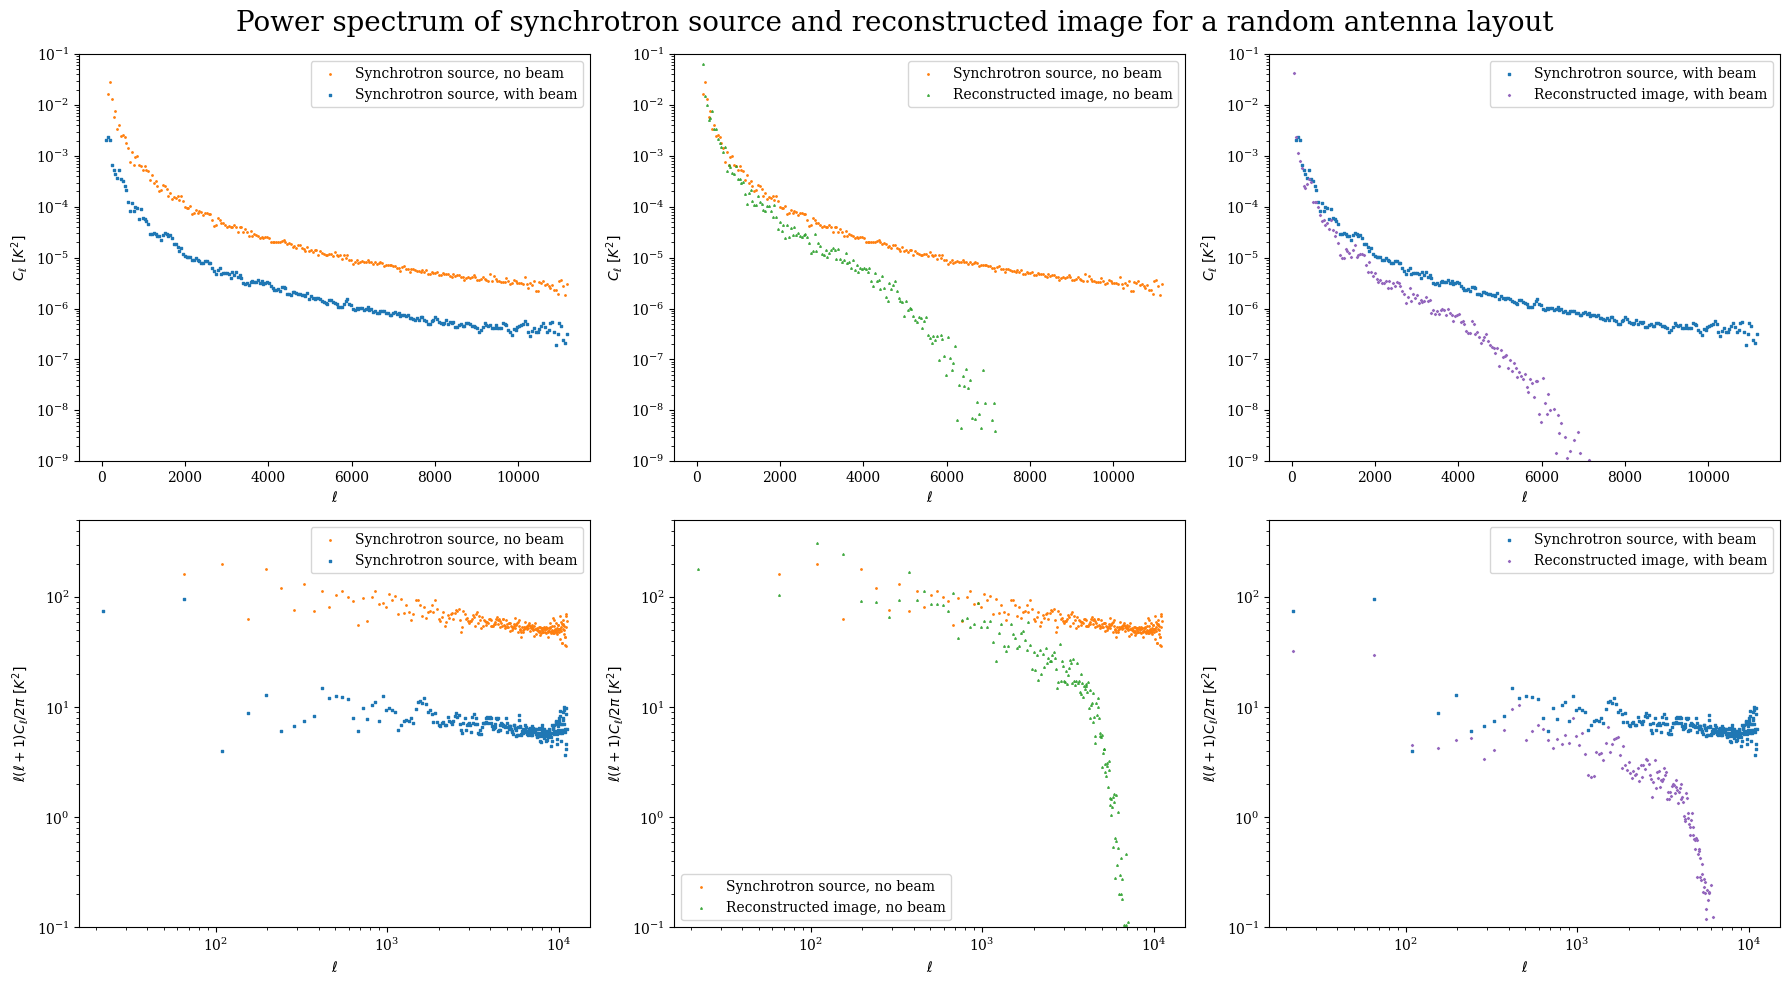

In [23]:
fig, axs= plt.subplots(2, 3, figsize=(18, 10))

plt.suptitle('Power spectrum of synchrotron source and reconstructed image for a random antenna layout', fontsize=20)

axs[0,0].scatter(synchrofft_source_nobm_bins_centre, synchrofft_source_nobm_binnedimg,
                label='Synchrotron source, no beam',
                color='tab:orange',
                marker='o',
                s=1)
axs[0,0].scatter(synchrofft_source_bm_bins_centre, synchrofft_source_bm_binnedimg,
                label='Synchrotron source, with beam',
                color='tab:blue',
                marker='s',
                s=1)
axs[0,0].set_xlabel(r'$\ell$')
axs[0,0].set_ylabel(r'$C_{\ell}$ $[K^2]$')
axs[0,0].set_yscale('log')
axs[0,0].set_ylim(1e-9, 1e-1)
axs[0,0].legend()

axs[0,1].scatter(synchrofft_source_nobm_bins_centre, synchrofft_source_nobm_binnedimg,
                label='Synchrotron source, no beam',
                color='tab:orange',
                marker='o',
                s=1)
axs[0,1].scatter(synchrofft_nobm_bins_centre, synchrofft_nobm_binnedimg,
                label='Reconstructed image, no beam',
                color='tab:green',
                marker='^',
                s=1)
axs[0,1].set_xlabel(r'$\ell$')
axs[0,1].set_ylabel(r'$C_{\ell}$ $[K^2]$')
axs[0,1].set_yscale('log')
axs[0,1].set_ylim(1e-9, 1e-1)
axs[0,1].legend()

axs[0,2].scatter(synchrofft_source_bm_bins_centre, synchrofft_source_bm_binnedimg,
                label='Synchrotron source, with beam',
                color='tab:blue',
                marker='s',
                s=1)
axs[0,2].scatter(synchrofft_bm_bins_centre, synchrofft_bm_binnedimg,
                label='Reconstructed image, with beam',
                color='tab:purple',
                marker='D',
                s=1)
axs[0,2].set_xlabel(r'$\ell$')
axs[0,2].set_ylabel(r'$C_{\ell}$ $[K^2]$')
axs[0,2].set_yscale('log')
axs[0,2].set_ylim(1e-9, 1e-1)
axs[0,2].legend()

# ***********************************************
# 2nd row of plots, where the y axis is l*(l+1)*C_l / 2*pi

axs[1,0].scatter(synchrofft_source_nobm_bins_centre, synchrofft_source_nobm_bins_centre
                * (synchrofft_source_nobm_bins_centre + 1) 
                * synchrofft_source_nobm_binnedimg / (2*np.pi),
                label='Synchrotron source, no beam',
                color='tab:orange',
                marker='o',
                s=1)
axs[1,0].scatter(synchrofft_source_bm_bins_centre, synchrofft_source_bm_bins_centre
                * (synchrofft_source_bm_bins_centre + 1)
                *synchrofft_source_bm_binnedimg / (2*np.pi),
                label='Synchrotron source, with beam',
                color='tab:blue',
                marker='s',
                s=1)
axs[1,0].set_xlabel(r'$\ell$')
axs[1,0].set_ylabel(r'$\ell(\ell + 1)C_{\ell}/2\pi$ $[K^2]$')
axs[1,0].set_yscale('log')
axs[1,0].set_xscale('log')
axs[1,0].set_ylim(1e-1, 0.5*1e3)
axs[1,0].legend()

axs[1,1].scatter(synchrofft_source_nobm_bins_centre, synchrofft_source_nobm_bins_centre
                * (synchrofft_source_nobm_bins_centre + 1)
                * synchrofft_source_nobm_binnedimg / (2*np.pi),
                label='Synchrotron source, no beam',
                color='tab:orange',
                marker='o',
                s=1)
axs[1,1].scatter(synchrofft_nobm_bins_centre, synchrofft_nobm_bins_centre
                * (synchrofft_nobm_bins_centre + 1)
                * synchrofft_nobm_binnedimg / (2*np.pi),
                label='Reconstructed image, no beam',
                color='tab:green',
                marker='^',
                s=1)
axs[1,1].set_xlabel(r'$\ell$')
axs[1,1].set_ylabel(r'$\ell(\ell + 1)C_{\ell}/2\pi$ $[K^2]$')
axs[1,1].set_yscale('log')
axs[1,1].set_xscale('log')
axs[1,1].set_ylim(1e-1, 0.5*1e3)
axs[1,1].legend()

axs[1,2].scatter(synchrofft_source_bm_bins_centre, synchrofft_source_bm_bins_centre
                * (synchrofft_source_bm_bins_centre + 1)
                *synchrofft_source_bm_binnedimg / (2*np.pi),
                label='Synchrotron source, with beam',
                color='tab:blue',
                marker='s',
                s=1)
axs[1,2].scatter(synchrofft_bm_bins_centre, synchrofft_bm_bins_centre
                * (synchrofft_bm_bins_centre + 1)
                * synchrofft_bm_binnedimg / (2*np.pi),
                label='Reconstructed image, with beam',
                color='tab:purple',
                marker='D',
                s=1)
axs[1,2].set_xlabel(r'$\ell$')
axs[1,2].set_ylabel(r'$\ell(\ell + 1)C_{\ell}/2\pi$ $[K^2]$')
axs[1,2].set_yscale('log')
axs[1,2].set_xscale('log')
axs[1,2].set_ylim(1e-1, 0.5*1e3)
axs[1,2].legend()
plt.tight_layout()

filename= ("1Dpowerspec_5.8FoV_Z8.52_res256_RngPm[m]900_Ant11^2_D[m]45_random.png")
full_file_path= os.path.join(os.path.dirname("output/"), filename)
plt.savefig(full_file_path, dpi=300)

In [24]:
#__________GRID LAYOUT__________

#This is the binning for the synchrotron source with beam pattern
visls_synchro_bm, vismx_synchro_bm, bl_synchro_bm= visibility_matrix_func_new_method(xyz_grid, thet, rshift, synchro_source, beam_pattern)
bin_synchro_bm, uvbin_synchro_bm, uvsampl_synchro_bm, x_synchro_bm= image_reconstructing_func(visls_synchro_bm, bl_synchro_bm, uu[0], uu[-1], len(uu), 1)
synchrofft_bm_bins_centre, synchrofft_bm_binnedimg= powerspec_1d(uvbin_synchro_bm, bin_synchro_bm, FoV)

#This is the binning for the synchrotron source without beam pattern
visls_synchro_nobm, vismx_synchro_nobm, bl_synchro_nobm= visibility_matrix_func_new_method(xyz_grid, thet, rshift, synchro_source, np.ones_like(beam_pattern))
bin_synchro_nobm, uvbin_synchro_nobm, uvsampl_synchro_nobm, x_synchro_nobm= image_reconstructing_func(visls_synchro_nobm, bl_synchro_nobm, uu[0], uu[-1], len(uu), 1)
synchrofft_nobm_bins_centre, synchrofft_nobm_binnedimg= powerspec_1d(uvbin_synchro_nobm, bin_synchro_nobm, FoV)

#This is the binning for the source synchro image without beam pattern
synchro_source_fft_nobm= np.fft.fftshift(np.fft.fft2(synchro_source))
synchrofft_source_nobm_bins_centre, synchrofft_source_nobm_binnedimg= powerspec_1d(uu, synchro_source_fft_nobm, FoV)

#This is the binning for the source synchro image with beam pattern
synchro_source_fft_bm= np.fft.fftshift(np.fft.fft2(synchro_source * beam_pattern))
synchrofft_source_bm_bins_centre, synchrofft_source_bm_binnedimg= powerspec_1d(uu, synchro_source_fft_bm, FoV)

100%|██████████| 7260/7260 [00:34<00:00, 207.56it/s]


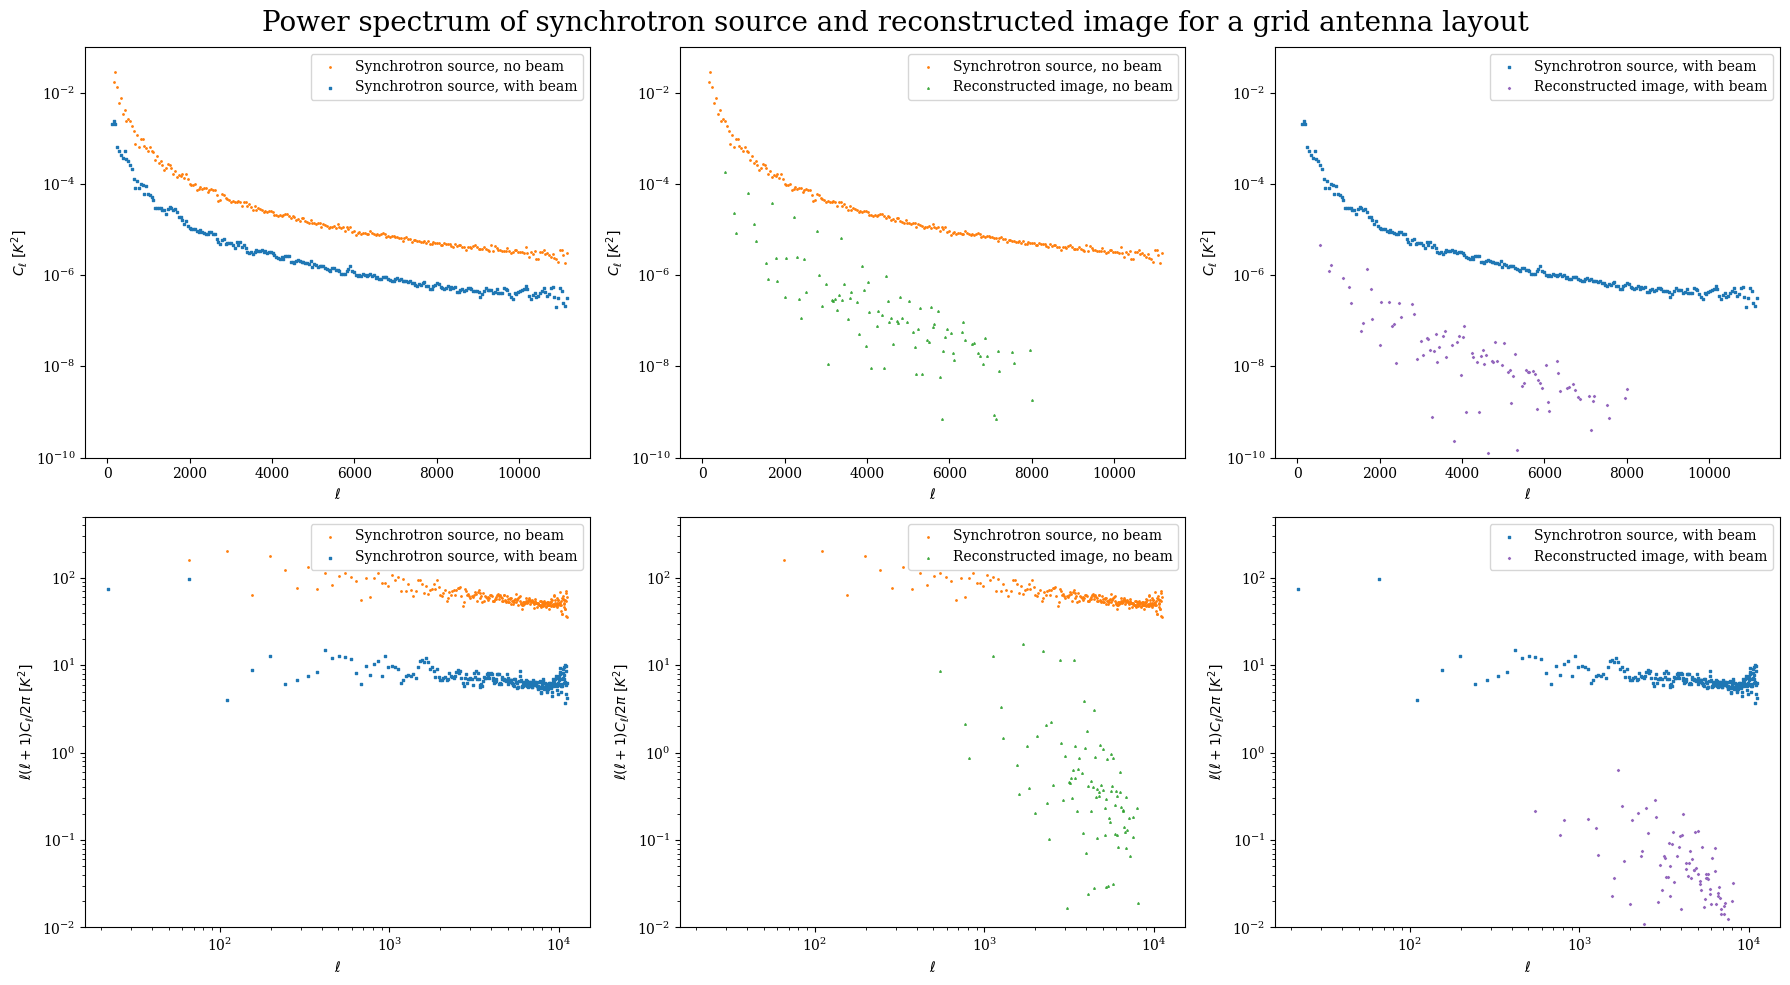

In [25]:
fig, axs= plt.subplots(2, 3, figsize=(18, 10))

plt.suptitle('Power spectrum of synchrotron source and reconstructed image for a grid antenna layout', fontsize=20)

axs[0,0].scatter(synchrofft_source_nobm_bins_centre, synchrofft_source_nobm_binnedimg,
                label='Synchrotron source, no beam',
                color='tab:orange',
                marker='o',
                s=1)
axs[0,0].scatter(synchrofft_source_bm_bins_centre, synchrofft_source_bm_binnedimg,
                label='Synchrotron source, with beam',
                color='tab:blue',
                marker='s',
                s=1)
axs[0,0].set_xlabel(r'$\ell$')
axs[0,0].set_ylabel(r'$C_{\ell}$ $[K^2]$')
axs[0,0].set_yscale('log')
axs[0,0].set_ylim(1e-10, 1e-1)
axs[0,0].legend()

axs[0,1].scatter(synchrofft_source_nobm_bins_centre, synchrofft_source_nobm_binnedimg,
                label='Synchrotron source, no beam',
                color='tab:orange',
                marker='o',
                s=1)
axs[0,1].scatter(synchrofft_nobm_bins_centre, synchrofft_nobm_binnedimg,
                label='Reconstructed image, no beam',
                color='tab:green',
                marker='^',
                s=1)
axs[0,1].set_xlabel(r'$\ell$')
axs[0,1].set_ylabel(r'$C_{\ell}$ $[K^2]$')
axs[0,1].set_yscale('log')
axs[0,1].set_ylim(1e-10, 1e-1)
axs[0,1].legend()

axs[0,2].scatter(synchrofft_source_bm_bins_centre, synchrofft_source_bm_binnedimg,
                label='Synchrotron source, with beam',
                color='tab:blue',
                marker='s',
                s=1)
axs[0,2].scatter(synchrofft_bm_bins_centre, synchrofft_bm_binnedimg,
                label='Reconstructed image, with beam',
                color='tab:purple',
                marker='D',
                s=1)
axs[0,2].set_xlabel(r'$\ell$')
axs[0,2].set_ylabel(r'$C_{\ell}$ $[K^2]$')
axs[0,2].set_yscale('log')
axs[0,2].set_ylim(1e-10, 1e-1)
axs[0,2].legend()

# ***********************************************
# 2nd row of plots, where the y axis is l*(l+1)*C_l / 2*pi

axs[1,0].scatter(synchrofft_source_nobm_bins_centre, synchrofft_source_nobm_bins_centre
                * (synchrofft_source_nobm_bins_centre + 1) 
                * synchrofft_source_nobm_binnedimg / (2*np.pi),
                label='Synchrotron source, no beam',
                color='tab:orange',
                marker='o',
                s=1)
axs[1,0].scatter(synchrofft_source_bm_bins_centre, synchrofft_source_bm_bins_centre
                * (synchrofft_source_bm_bins_centre + 1)
                *synchrofft_source_bm_binnedimg / (2*np.pi),
                label='Synchrotron source, with beam',
                color='tab:blue',
                marker='s',
                s=1)
axs[1,0].set_xlabel(r'$\ell$')
axs[1,0].set_ylabel(r'$\ell(\ell + 1)C_{\ell}/2\pi$ $[K^2]$')
axs[1,0].set_yscale('log')
axs[1,0].set_xscale('log')
axs[1,0].set_ylim(1e-2, 0.5*1e3)
axs[1,0].legend()

axs[1,1].scatter(synchrofft_source_nobm_bins_centre, synchrofft_source_nobm_bins_centre
                * (synchrofft_source_nobm_bins_centre + 1)
                * synchrofft_source_nobm_binnedimg / (2*np.pi),
                label='Synchrotron source, no beam',
                color='tab:orange',
                marker='o',
                s=1)
axs[1,1].scatter(synchrofft_nobm_bins_centre, synchrofft_nobm_bins_centre
                * (synchrofft_nobm_bins_centre + 1)
                * synchrofft_nobm_binnedimg / (2*np.pi),
                label='Reconstructed image, no beam',
                color='tab:green',
                marker='^',
                s=1)
axs[1,1].set_xlabel(r'$\ell$')
axs[1,1].set_ylabel(r'$\ell(\ell + 1)C_{\ell}/2\pi$ $[K^2]$')
axs[1,1].set_yscale('log')
axs[1,1].set_xscale('log')
axs[1,1].set_ylim(1e-2, 0.5*1e3)
axs[1,1].legend()

axs[1,2].scatter(synchrofft_source_bm_bins_centre, synchrofft_source_bm_bins_centre
                * (synchrofft_source_bm_bins_centre + 1)
                *synchrofft_source_bm_binnedimg / (2*np.pi),
                label='Synchrotron source, with beam',
                color='tab:blue',
                marker='s',
                s=1)
axs[1,2].scatter(synchrofft_bm_bins_centre, synchrofft_bm_bins_centre
                * (synchrofft_bm_bins_centre + 1)
                * synchrofft_bm_binnedimg / (2*np.pi),
                label='Reconstructed image, with beam',
                color='tab:purple',
                marker='D',
                s=1)
axs[1,2].set_xlabel(r'$\ell$')
axs[1,2].set_ylabel(r'$\ell(\ell + 1)C_{\ell}/2\pi$ $[K^2]$')
axs[1,2].set_yscale('log')
axs[1,2].set_xscale('log')
axs[1,2].set_ylim(1e-2, 0.5*1e3)
axs[1,2].legend()
plt.tight_layout()

filename= ("1Dpowerspec_5.8FoV_Z8.52_res256_RngPm[m]900_Ant11^2_D[m]45_grid.png")
full_file_path= os.path.join(os.path.dirname("output/"), filename)
plt.savefig(full_file_path, dpi=300)